# Module 06 — Clustering with Resolution Optimization (v5 + tiered v4)

This notebook visualizes clustering results from `scripts/06_clustering.py`
for **both** the v5 atlas (CCA-flat) and the new **tiered v4 atlas**
(Seurat v4 SCT + CCA, run per compartment with mesenchymal / non-mesenchymal
tiers split before integration). Leiden clustering is run per tier on the
tier-specific embedding with automated resolution optimization.

**Sections**
- §1–4 — v5 atlas (CCA-flat, status: completed 2026-03-25)
- §5 — tiered v4 atlas (status: Module 06 complete 2026-05-06; pending human checkpoint)

**v5 cluster counts:** NP 12 · AF 12 · CEP 9 · all_cells 15

**Tiered v4 cluster counts:** NP 29 · AF 9 · CEP 11 · all_cells 21

**Data sources**
- v5: `data/integrated/{NP,AF,CEP,all_cells}.h5ad` · `results/integration/clustering_resolution_optimization/`
- tiered v4: `data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad` · `results/integration/tiered_v4/clustering_resolution_optimization/`


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

import io
from pathlib import Path

import anndata
anndata.settings.allow_write_nullable_strings = True

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from PIL import Image as PILImage
from IPython.display import Image, display, Markdown

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# JPEG-compression helpers — keep notebook under GitHub's ~10 MB render limit.
# Source figures stay full-resolution in results/.
UMAP_MAX_WIDTH = 1200
UMAP_JPEG_QUALITY = 90

def _encode_jpeg(img, max_width=UMAP_MAX_WIDTH, quality=UMAP_JPEG_QUALITY):
    img = img.convert('RGB')
    if img.width > max_width:
        ratio = max_width / img.width
        img = img.resize((max_width, int(img.height * ratio)), PILImage.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality, optimize=True)
    return buf.getvalue()

def render_fig(fig, max_width=UMAP_MAX_WIDTH, quality=UMAP_JPEG_QUALITY, dpi=110):
    """Render a matplotlib figure through the PIL/JPEG pipeline."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    jpeg_bytes = _encode_jpeg(PILImage.open(buf), max_width, quality)
    display(Image(data=jpeg_bytes, format='jpeg'))

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
INT_DIR = BASE / 'data' / 'integrated'
OPT_DIR = BASE / 'results' / 'integration' / 'clustering_resolution_optimization'
FIG_DIR = BASE / 'results' / 'integration'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COMPARTMENTS = {
    'NP': INT_DIR / 'NP.h5ad',
    'AF': INT_DIR / 'AF.h5ad',
    'CEP': INT_DIR / 'CEP.h5ad',
    'all_cells': INT_DIR / 'all_cells.h5ad',
}

for name, path in COMPARTMENTS.items():
    print(f'  {name}: {"found" if path.exists() else "NOT FOUND"}')


  NP: found
  AF: found
  CEP: found
  all_cells: found


## 1. Resolution Optimization Diagnostics (v5)

The resolution parameter controls the granularity of Leiden clustering. A
resolution scan evaluates multiple values and selects the one that optimizes
a combination of silhouette score and cluster stability. Plots below show
the optimization landscape for each compartment and tier.


Resolution optimization plots: 8


### Af Mesenchymal

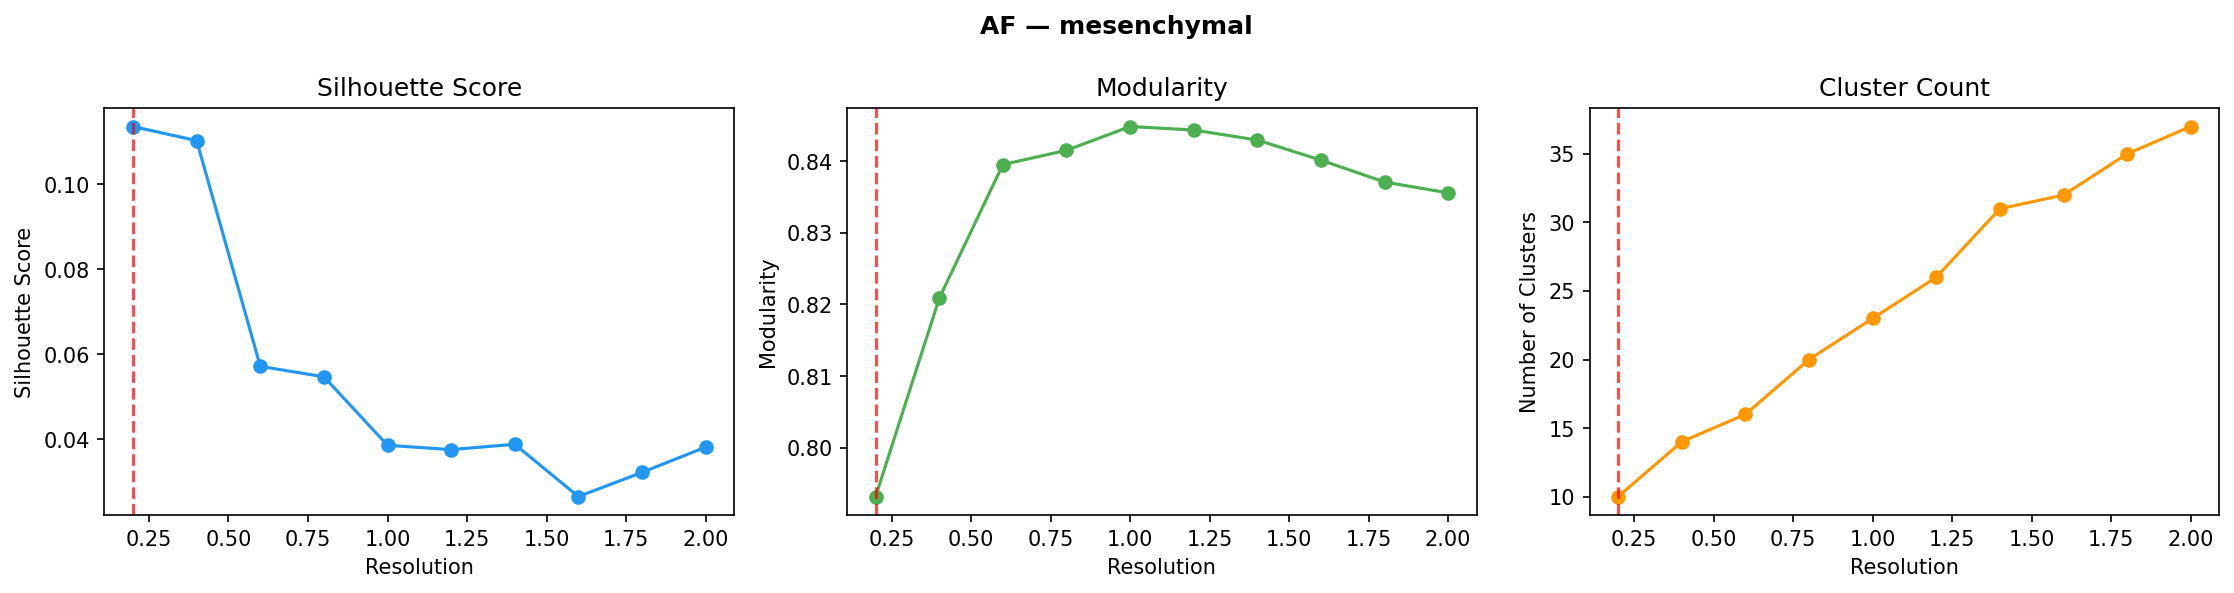

### Af Non Mesenchymal

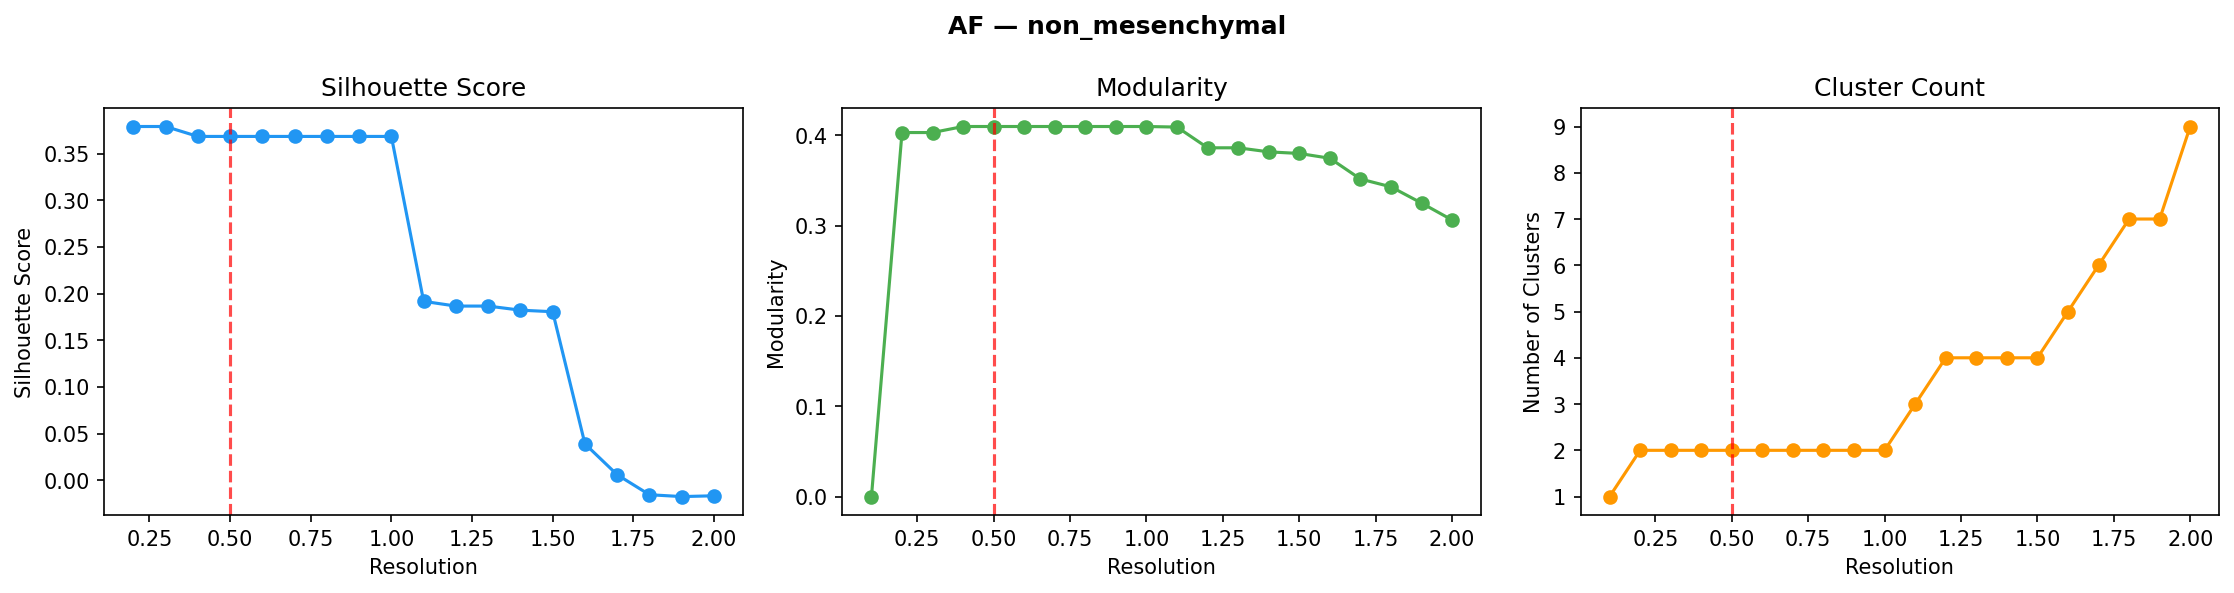

### Cep Mesenchymal

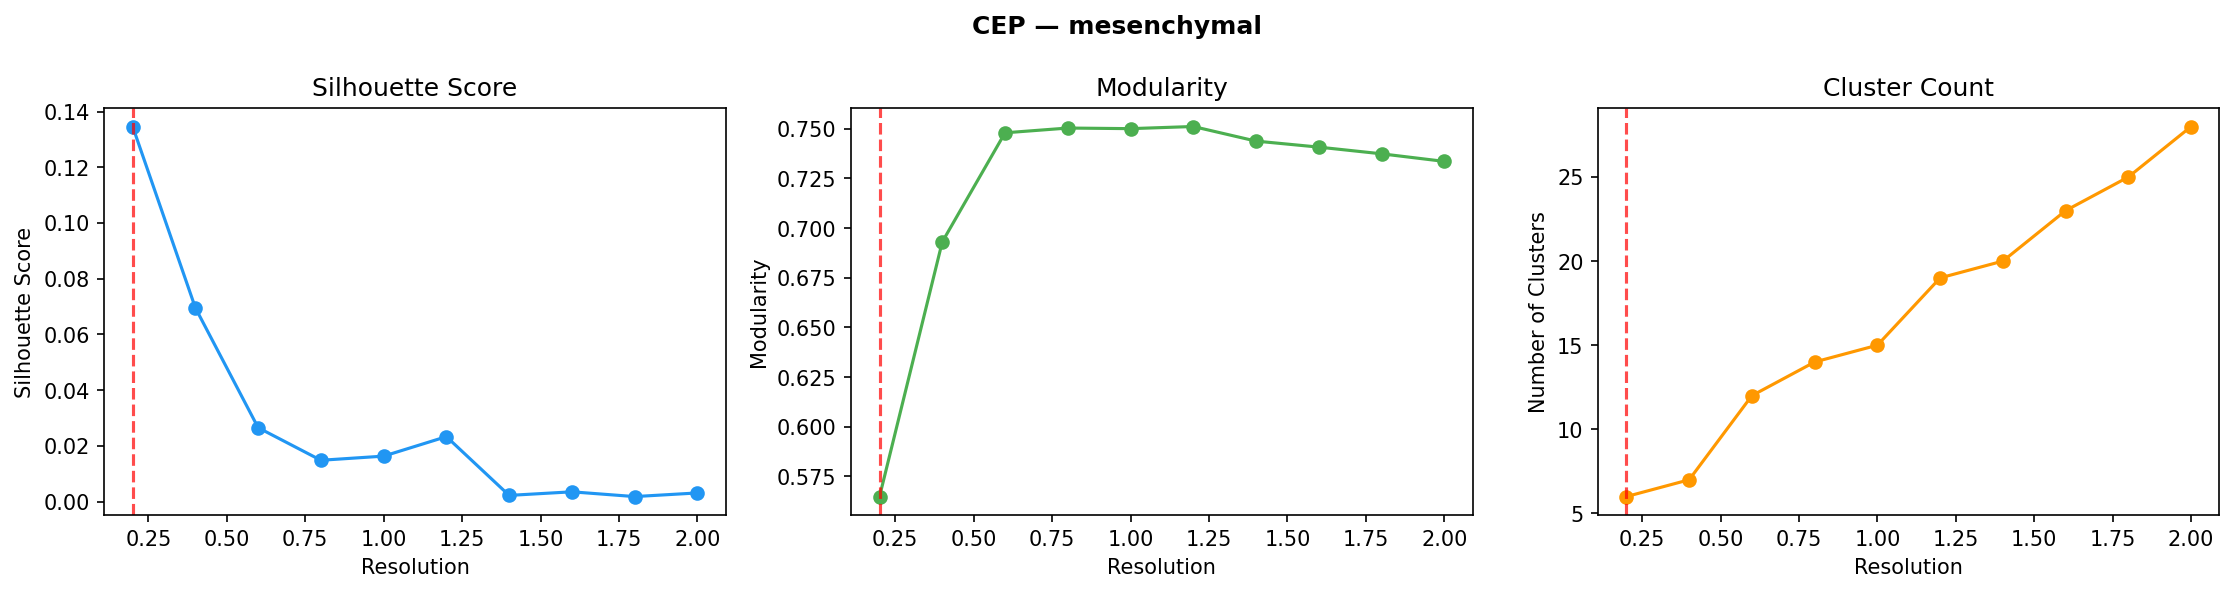

### Cep Non Mesenchymal

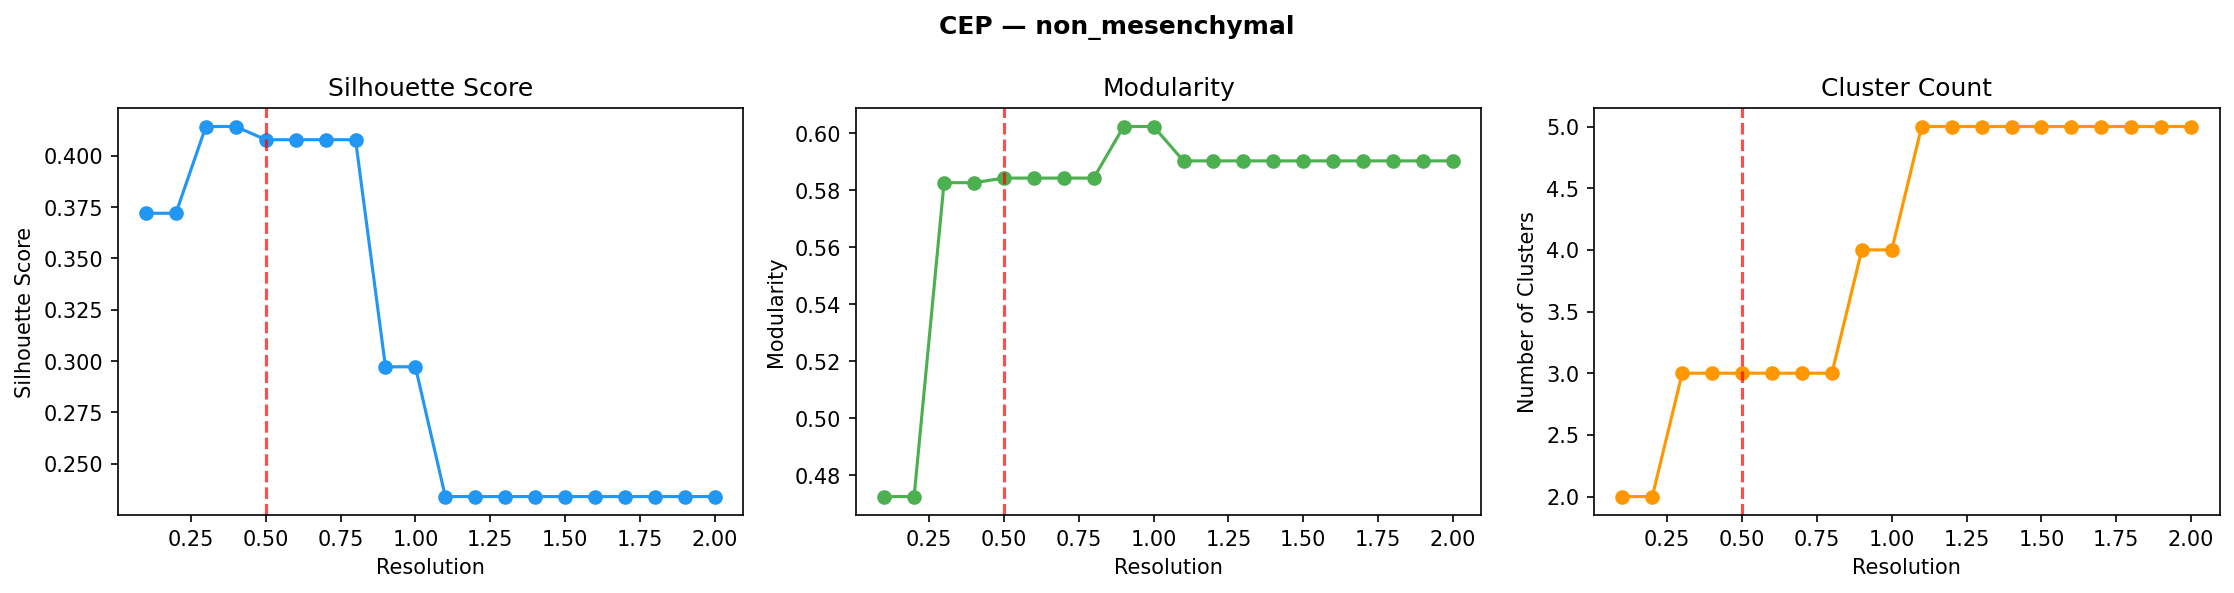

### Np Mesenchymal

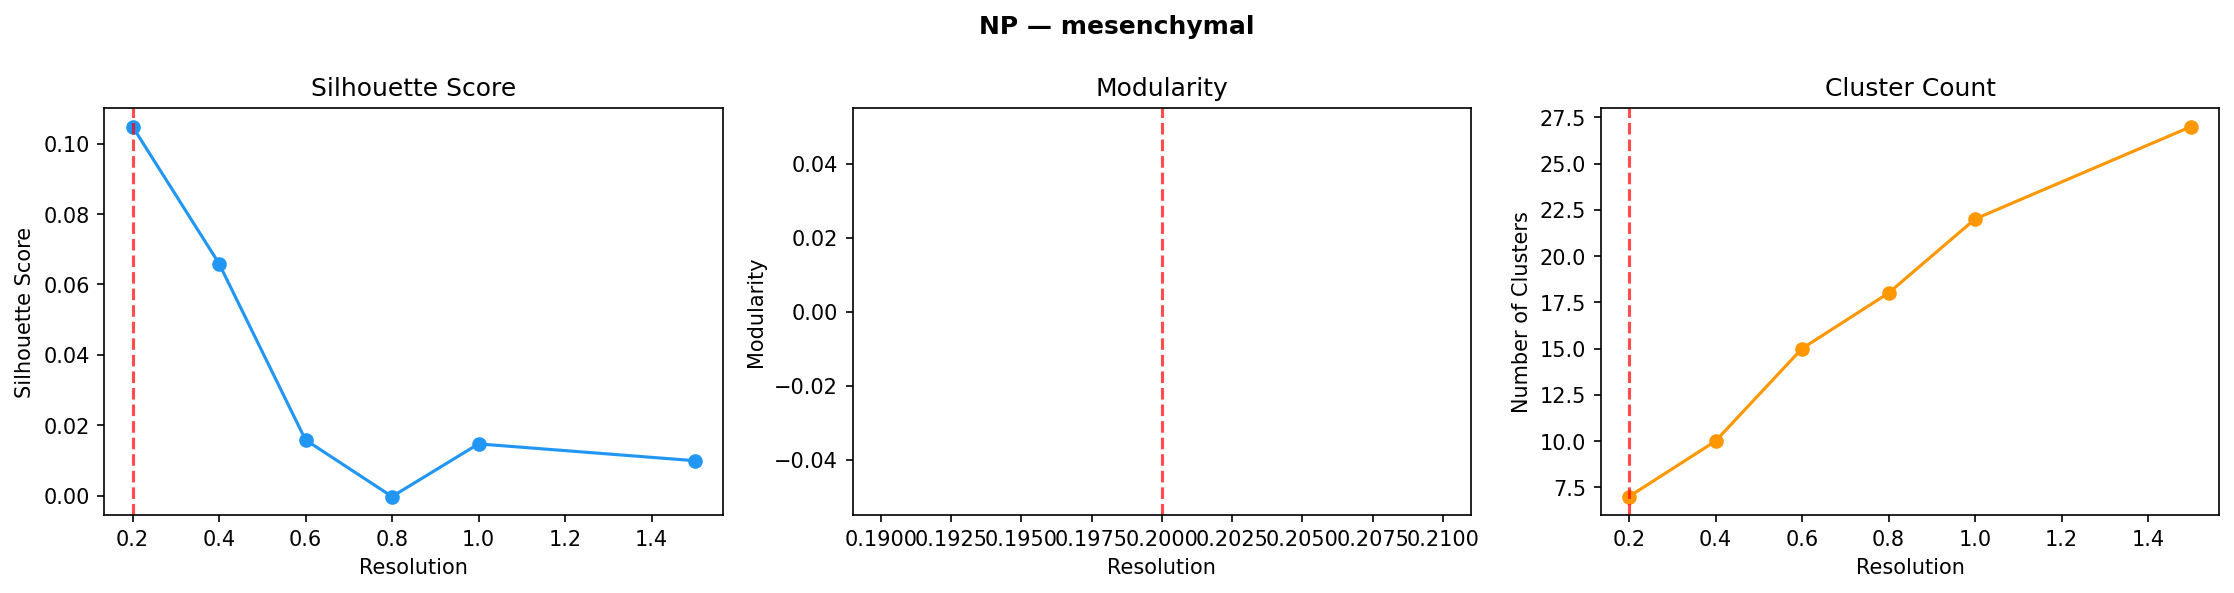

### Np Non Mesenchymal

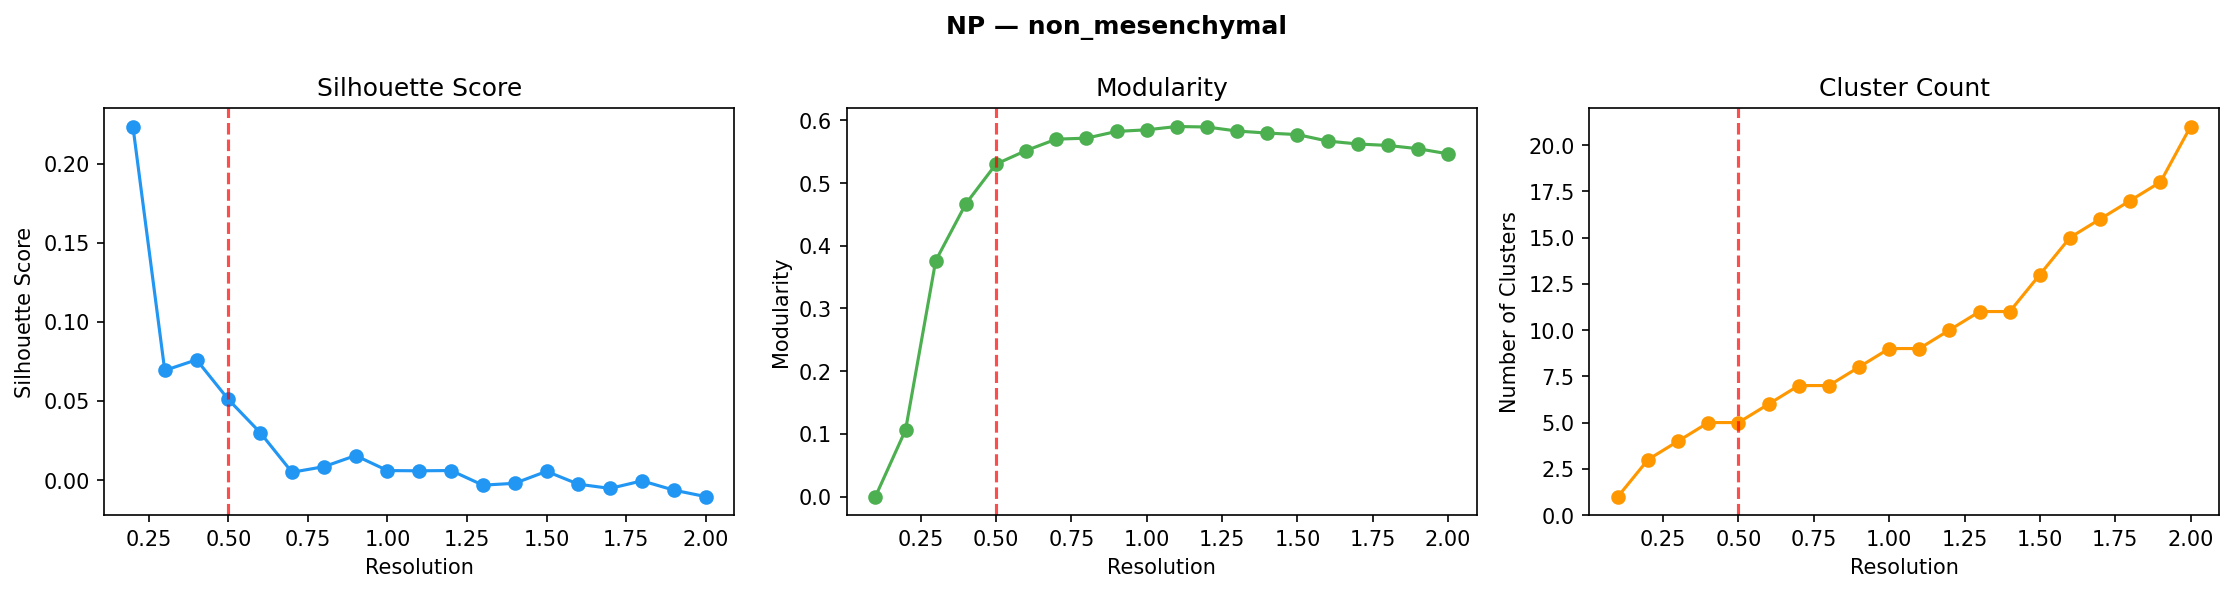

### All Cells Mesenchymal

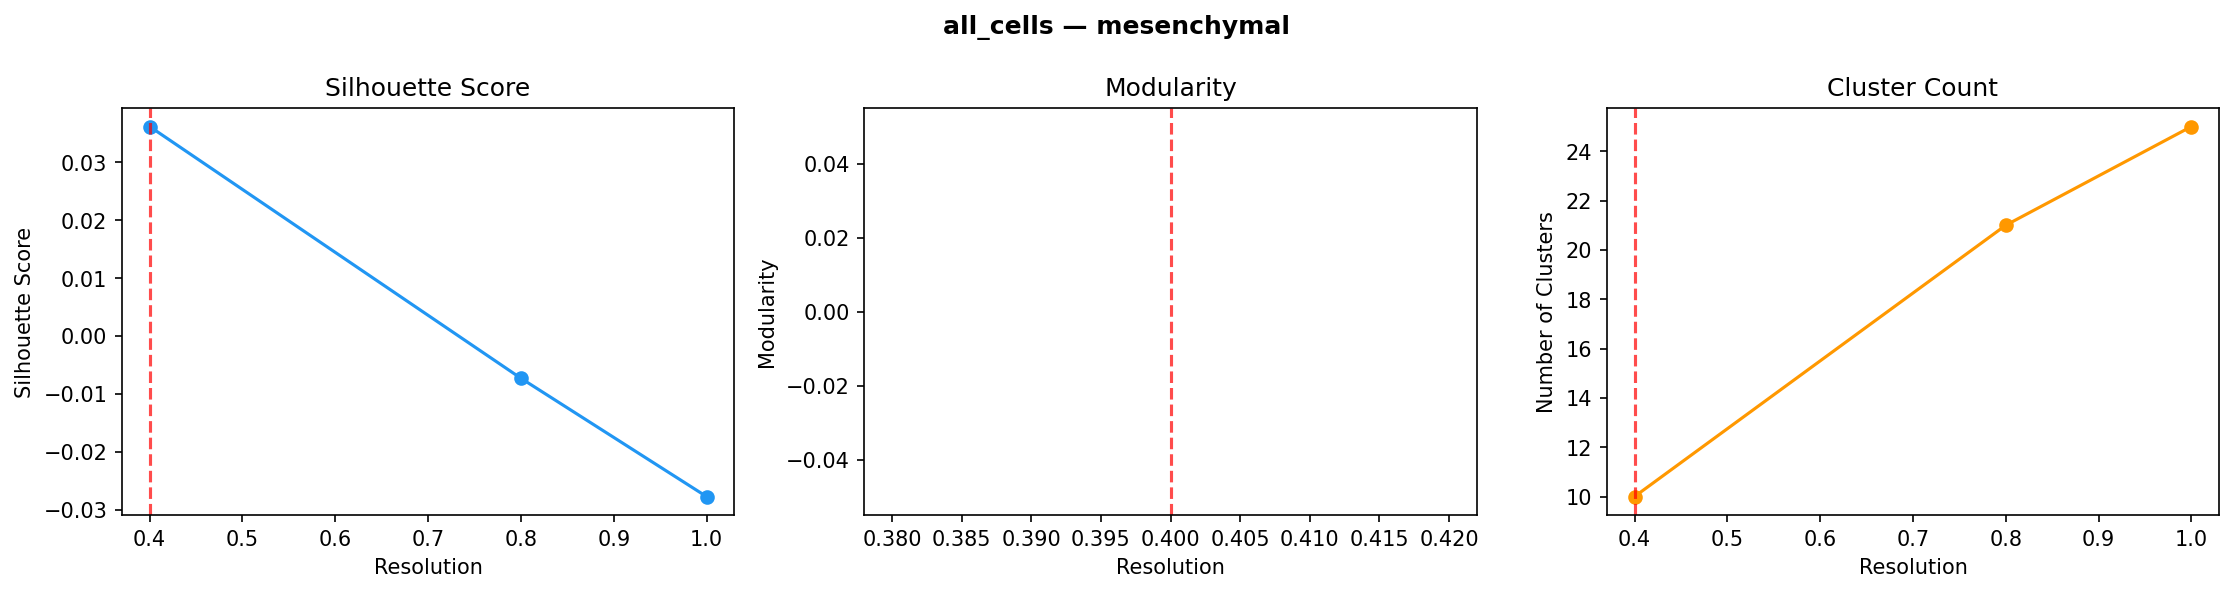

### All Cells Non Mesenchymal

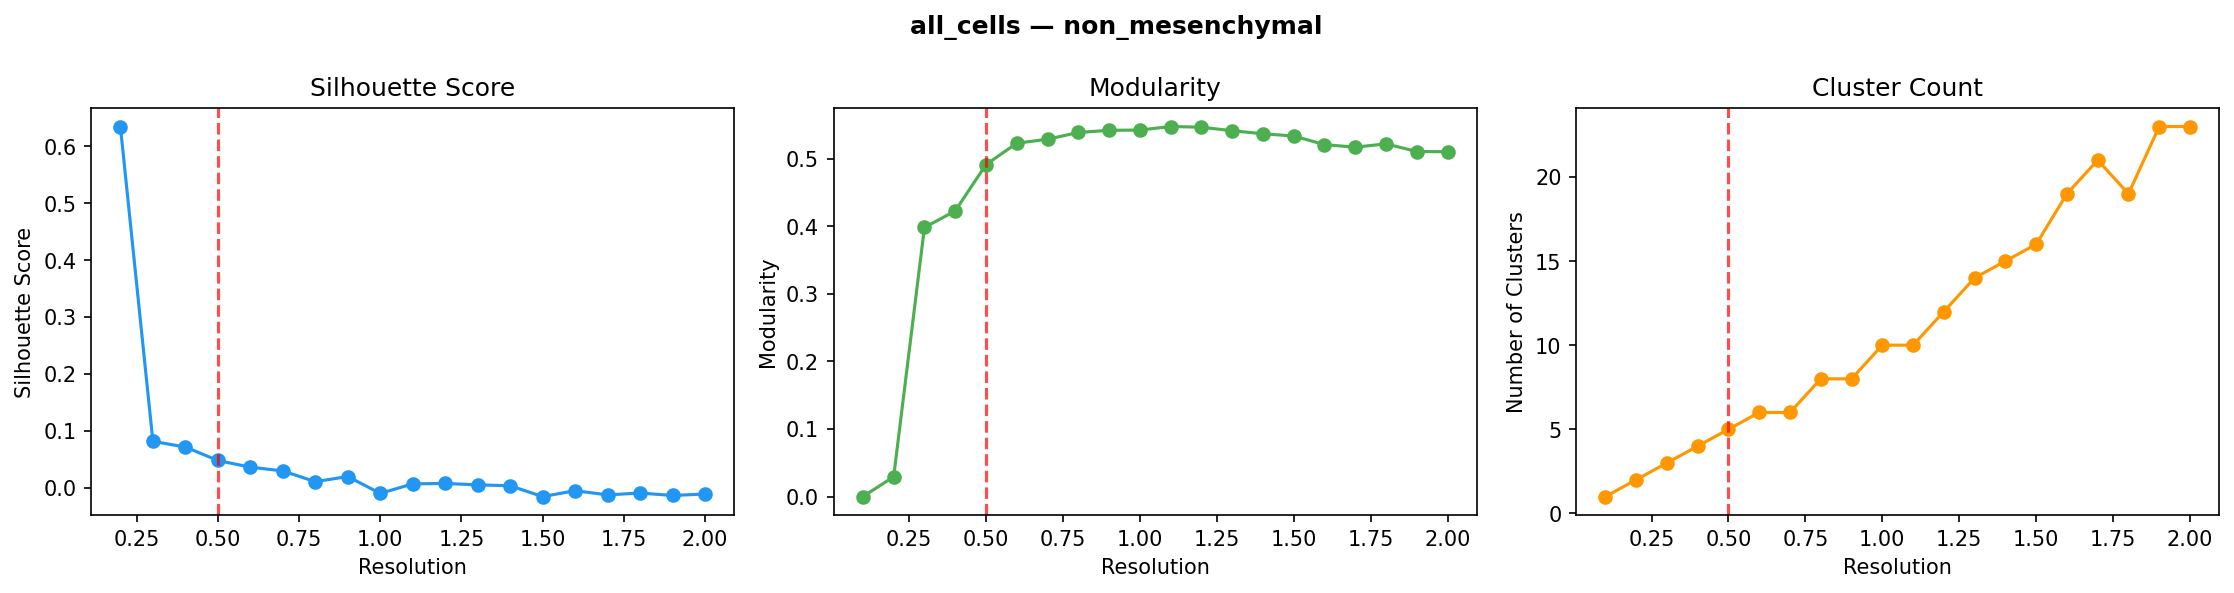

In [2]:
# Display resolution optimization plots for each compartment/tier
opt_plots = sorted(OPT_DIR.glob('*_optimization.png'))
print(f'Resolution optimization plots: {len(opt_plots)}')

for fpath in opt_plots:
    label = fpath.stem.replace('_optimization', '').replace('_', ' ').title()
    display(Markdown(f'### {label}'))
    display(Image(filename=str(fpath), width=800))

## 2. Resolution Scan Tables (v5)

Selected resolutions and metrics for each compartment/tier combination.


In [3]:
# Display resolution scan tables
res_tables = sorted(OPT_DIR.glob('*_resolutions.tsv'))
print(f'Resolution scan tables: {len(res_tables)}')

for fpath in res_tables:
    label = fpath.stem.replace('_resolutions', '').replace('_', ' ').title()
    df = pd.read_csv(fpath, sep='\t')
    display(Markdown(f'### {label}'))
    display(df.style.set_caption(f'{label} — Resolution Scan Results'))

Resolution scan tables: 8


### Af Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.200000,10,0.113650,0.793193
1,0.400000,14,0.110320,0.820853
2,0.600000,16,0.057175,0.839526
3,0.800000,20,0.054726,0.841514
4,1.000000,23,0.038593,0.844837
5,1.200000,26,0.037576,0.844344
6,1.400000,31,0.038834,0.842949
7,1.600000,32,0.026518,0.840142
8,1.800000,35,0.032216,0.837089
9,2.000000,37,0.038148,0.835573


### Af Non Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.100000,1,nan,0.000000
1,0.200000,2,0.378921,0.403187
2,0.300000,2,0.378921,0.403187
3,0.400000,2,0.368282,0.409869
4,0.500000,2,0.368282,0.409869
5,0.600000,2,0.368282,0.409869
6,0.700000,2,0.368282,0.409869
7,0.800000,2,0.368282,0.409869
8,0.900000,2,0.368282,0.409869
9,1.000000,2,0.368282,0.409869


...

,resolution,n_clusters,silhouette,modularity
0,0.100000,1,nan,0.000000
1,0.200000,3,0.223412,0.106312
2,0.300000,4,0.069269,0.376228
3,0.400000,5,0.076017,0.467009
4,0.500000,5,0.050921,0.530321
5,0.600000,6,0.030003,0.551945
6,0.700000,7,0.004937,0.570122
7,0.800000,7,0.008447,0.571688
8,0.900000,8,0.015479,0.582442
9,1.000000,9,0.005999,0.585001


### All Cells Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.400000,10,0.036124,nan
1,0.800000,21,-0.007291,nan
2,1.000000,25,-0.027690,nan


### All Cells Non Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.100000,1,nan,0.000000
1,0.200000,2,0.634397,0.029309
2,0.300000,3,0.081752,0.398008
3,0.400000,4,0.071703,0.422472
4,0.500000,5,0.048110,0.491067
5,0.600000,6,0.036371,0.522642
6,0.700000,6,0.029799,0.528545
7,0.800000,8,0.010896,0.538557
8,0.900000,8,0.019994,0.541758
9,1.000000,10,-0.009644,0.542107


## 3. Cluster UMAP per Compartment (v5)

UMAP colored by Leiden cluster labels for each compartment. This shows the
spatial distribution of clusters on the CCA-integrated embedding.


### NP — 12 Leiden Clusters

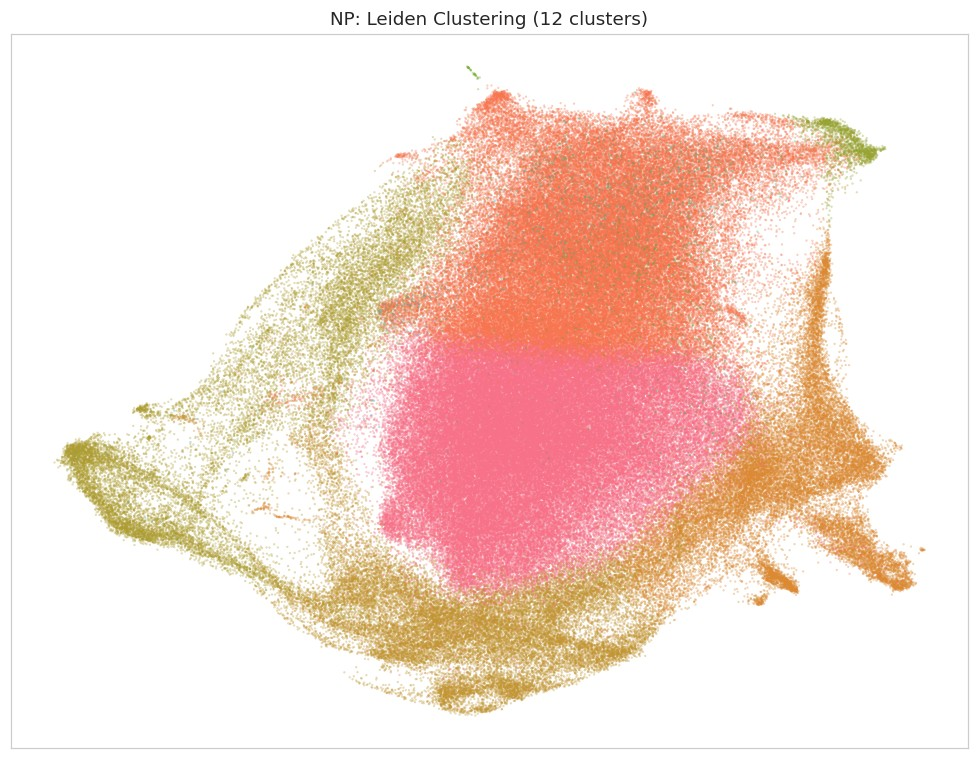

### AF — 12 Leiden Clusters

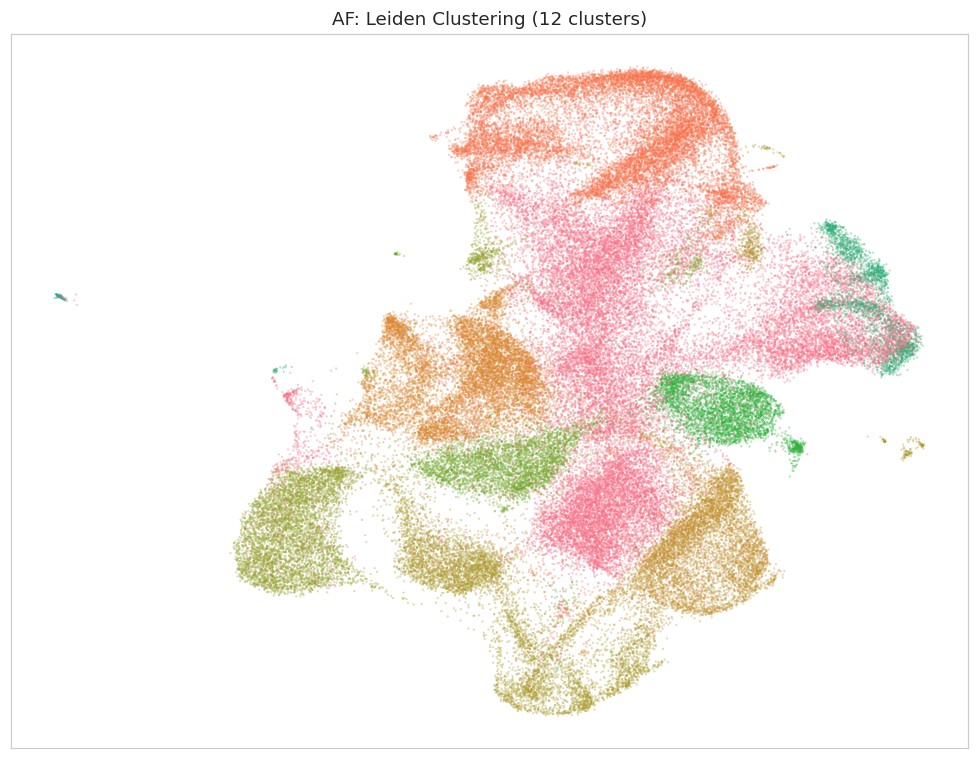

### CEP — 9 Leiden Clusters

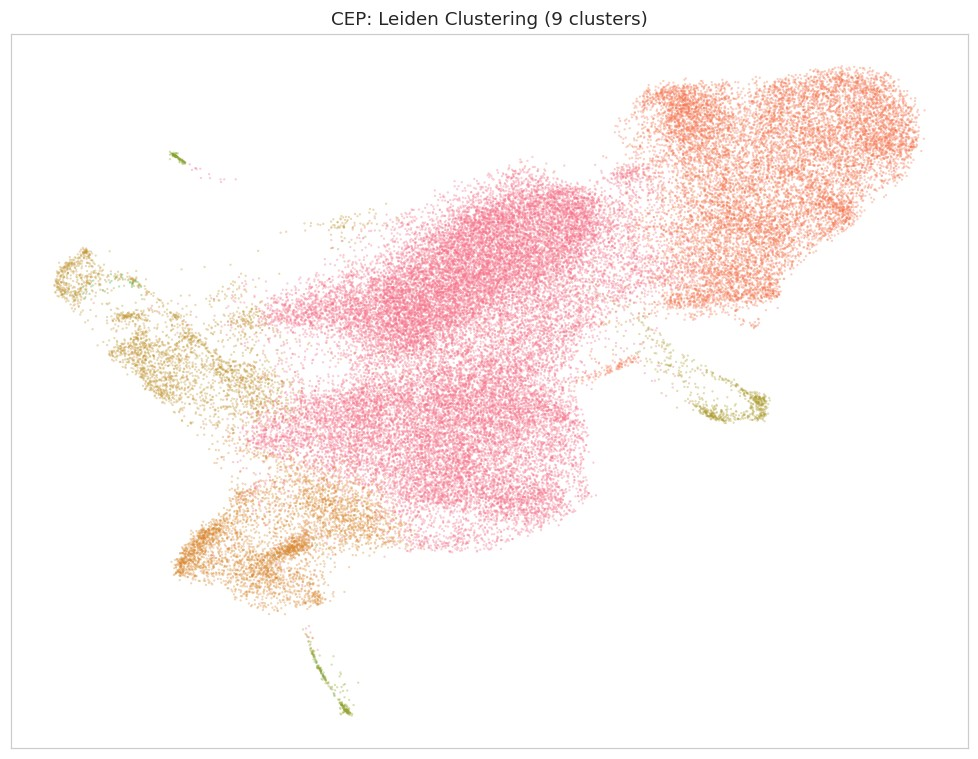

In [4]:
for comp_name, comp_path in [('NP', COMPARTMENTS['NP']),
                              ('AF', COMPARTMENTS['AF']),
                              ('CEP', COMPARTMENTS['CEP'])]:
    if not comp_path.exists():
        print(f'{comp_name}: file not found')
        continue

    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    umap = adata.obsm['X_umap'][:] if 'X_umap' in adata.obsm else None
    n_clusters = obs_df['leiden'].nunique() if 'leiden' in obs_df.columns else 0
    adata.file.close()

    if umap is None or 'leiden' not in obs_df.columns:
        print(f'{comp_name}: missing UMAP or leiden column')
        continue

    display(Markdown(f'### {comp_name} — {n_clusters} Leiden Clusters'))

    unique_clusters = sorted(obs_df['leiden'].unique(),
                              key=lambda x: int(x) if str(x).isdigit() else x)
    palette = dict(zip(unique_clusters,
                       sns.color_palette('husl', max(len(unique_clusters), 20))))

    fig, ax = plt.subplots(figsize=(9, 7))
    idx = np.random.RandomState(42).permutation(len(umap))
    labels = obs_df['leiden'].values
    colors = [palette.get(labels[i], '#cccccc') for i in idx]
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=0.2, alpha=0.4, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{comp_name}: Leiden Clustering ({n_clusters} clusters)', fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'notebook_06_{comp_name}_leiden_umap.png', dpi=150, bbox_inches='tight')
    render_fig(fig)

    del obs_df, umap


## 4. Cluster Size Distributions (v5)

Bar chart of cluster sizes for each compartment, showing how cells are
distributed across clusters.


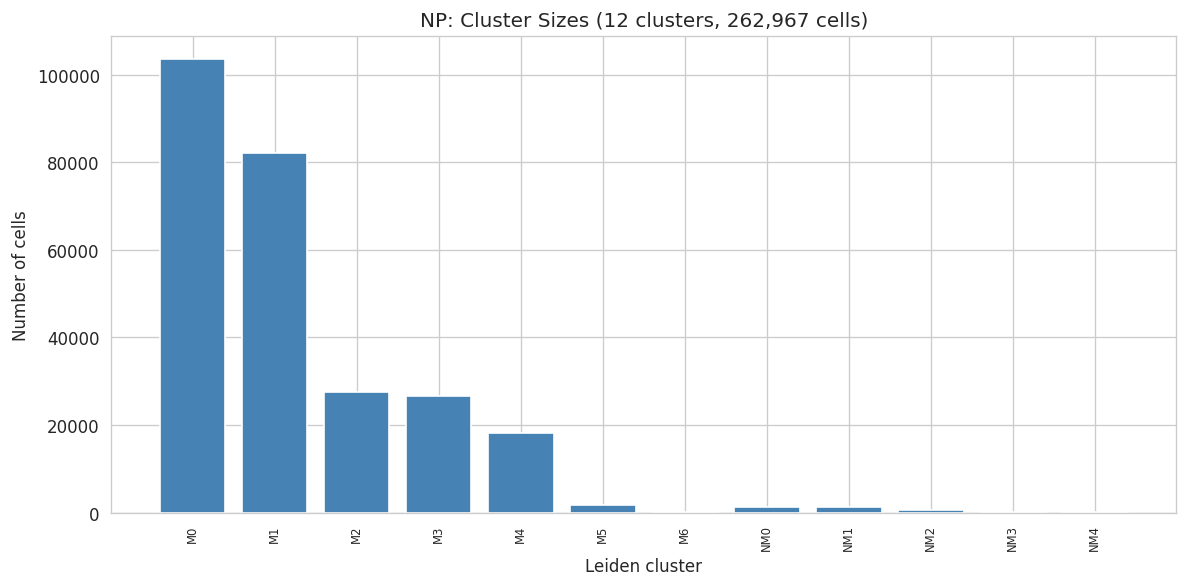

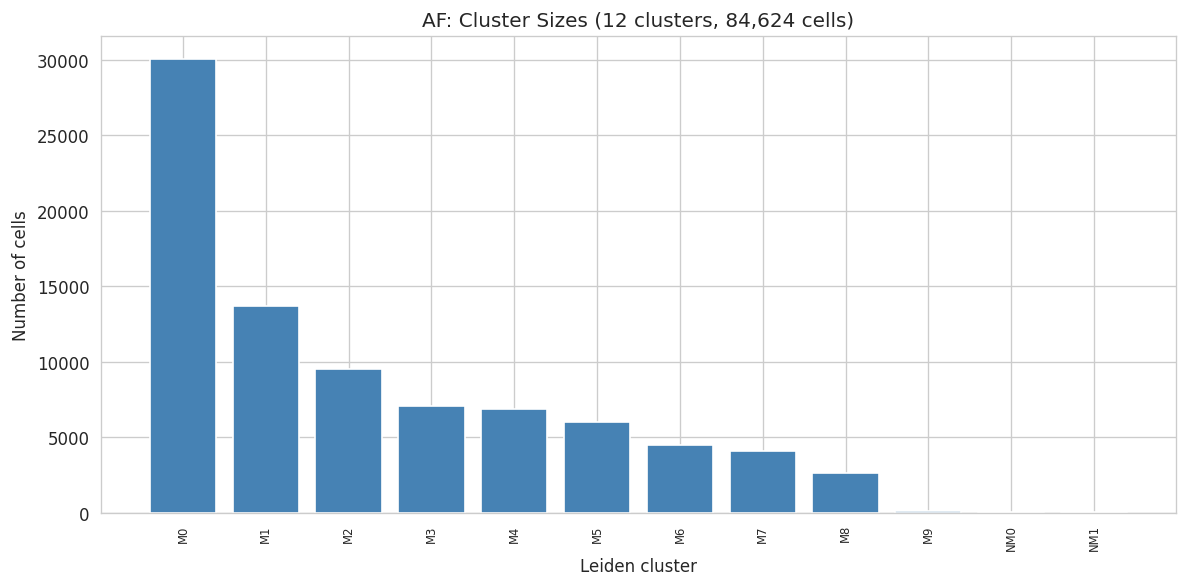

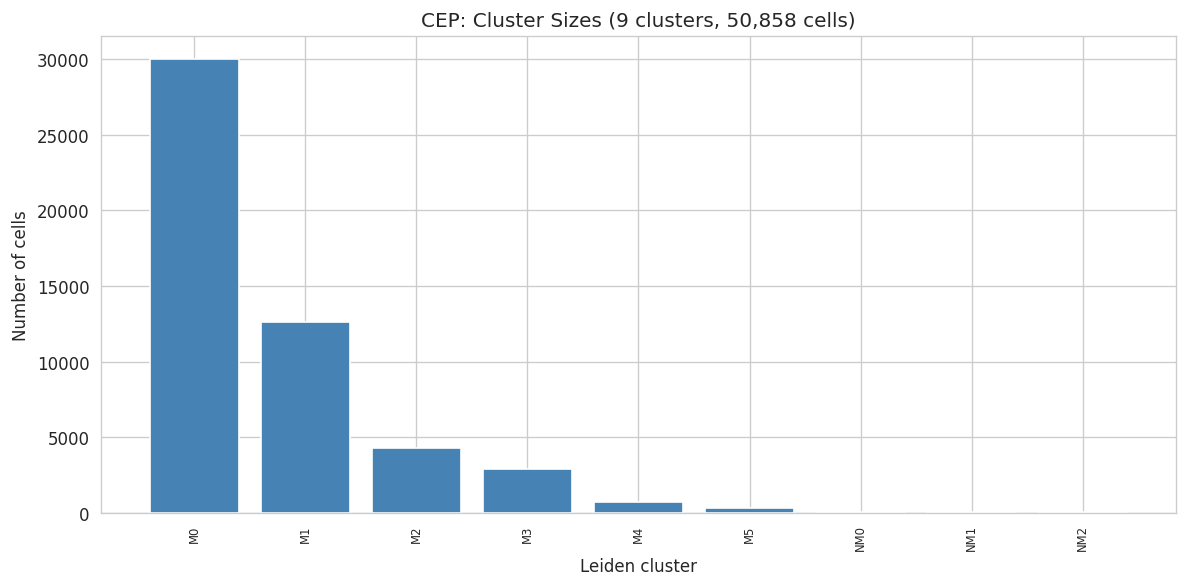

In [5]:
# Cluster size bar charts per compartment
for comp_name, comp_path in [('NP', COMPARTMENTS['NP']),
                              ('AF', COMPARTMENTS['AF']),
                              ('CEP', COMPARTMENTS['CEP'])]:
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()

    if 'leiden' not in obs_df.columns:
        continue

    counts = obs_df['leiden'].value_counts().sort_index(
        key=lambda x: x.astype(int) if x.str.isdigit().all() else x)

    fig, ax = plt.subplots(figsize=(max(10, len(counts) * 0.35), 5))
    ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=90, fontsize=7)
    ax.set_ylabel('Number of cells')
    ax.set_xlabel('Leiden cluster')
    ax.set_title(f'{comp_name}: Cluster Sizes ({len(counts)} clusters, {len(obs_df):,} cells)')
    fig.tight_layout()
    plt.show()

    del obs_df

## 5. Tiered v4 Atlas — Module 06 (2026-05-06)

After the per-compartment metric review (notebook 05 §6), the atlas was
re-run on the tiered v4 integration (Seurat v4 SCT + CCA, mesenchymal /
non-mesenchymal split before integration). Cells live at
`data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad`; the v5 outputs
remain on disk untouched. Module 06 ran independently per compartment via
`scripts/06_clustering.py --input-dir data/integrated/tiered_v4 \
--output-dir results/integration/tiered_v4`.

**2026-05-06 reruns** picked up three behaviour changes (commits `0886c50`,
`562adcd`, `f8d5940`):

- The non-mesenchymal `min_resolution = 0.5` floor was dropped — the silhouette
  peak is now taken over the full sweep.
- Modularity is computed for every resolution, regardless of cell count
  (previously skipped above 100 K cells).
- 05k AF tier-export threshold was raised to ≥ 5 cells per study, which let an
  AF non-mesenchymal tier be created for the first time (56 cells, 2 clusters).
- Non-mes tiers below the CCA dims threshold fall back to `integrate_simple`,
  and 05m auto-detects on-disk tiers per compartment.

**Status:** Module 06 complete; pipeline stopped at the human checkpoint
before Module 07. See open questions in §5f.


In [6]:
TV4_INT_DIR = BASE / 'data' / 'integrated' / 'tiered_v4'
TV4_OPT_DIR = BASE / 'results' / 'integration' / 'tiered_v4' / 'clustering_resolution_optimization'

TV4_COMPARTMENTS = {
    'NP':        TV4_INT_DIR / 'NP.h5ad',
    'AF':        TV4_INT_DIR / 'AF.h5ad',
    'CEP':       TV4_INT_DIR / 'CEP.h5ad',
    'all_cells': TV4_INT_DIR / 'all_cells.h5ad',
}

for name, path in TV4_COMPARTMENTS.items():
    size_gb = path.stat().st_size / 1e9 if path.exists() else 0.0
    status = 'found' if path.exists() else 'NOT FOUND'
    print(f'  {name:9s}: {status:9s}  ({size_gb:5.2f} GB)')


  NP       : found      ( 6.45 GB)
  AF       : found      ( 2.59 GB)
  CEP      : found      ( 1.27 GB)
  all_cells: found      (10.82 GB)


### 5a. Cluster count comparison (v5 vs tiered v4)


In [7]:
rows = []
for comp, v4_path in TV4_COMPARTMENTS.items():
    v5_path = COMPARTMENTS[comp]
    rec = {'compartment': comp}
    if v5_path.exists():
        a5 = sc.read_h5ad(v5_path, backed='r')
        obs5 = a5.obs.to_memory() if hasattr(a5.obs, 'to_memory') else a5.obs.copy()
        rec['v5_cells'] = len(obs5)
        rec['v5_n_clusters'] = obs5['leiden'].nunique() if 'leiden' in obs5.columns else None
        a5.file.close()
    else:
        rec['v5_cells'] = rec['v5_n_clusters'] = None

    a4 = sc.read_h5ad(v4_path, backed='r')
    obs4 = a4.obs.to_memory() if hasattr(a4.obs, 'to_memory') else a4.obs.copy()
    rec['v4_cells'] = len(obs4)
    rec['v4_n_clusters'] = obs4['leiden'].nunique() if 'leiden' in obs4.columns else None
    if 'leiden_mesenchymal' in obs4.columns:
        m = obs4['leiden_mesenchymal'].astype(str)
        rec['v4_mes_clusters'] = m[m != 'NA'].nunique()
        rec['v4_mes_cells'] = int((m != 'NA').sum())
    if 'leiden_non_mesenchymal' in obs4.columns:
        nm = obs4['leiden_non_mesenchymal'].astype(str)
        rec['v4_nonmes_clusters'] = nm[nm != 'NA'].nunique()
        rec['v4_nonmes_cells'] = int((nm != 'NA').sum())
    else:
        rec['v4_nonmes_clusters'] = '—'
        rec['v4_nonmes_cells'] = '—'
    a4.file.close()
    rows.append(rec)

cmp_df = pd.DataFrame(rows).set_index('compartment')[
    ['v5_cells', 'v5_n_clusters', 'v4_cells', 'v4_n_clusters',
     'v4_mes_clusters', 'v4_mes_cells', 'v4_nonmes_clusters', 'v4_nonmes_cells']]
display(cmp_df.style.set_caption('v5 (CCA-flat) vs tiered v4 — cells and cluster counts'))


,v5_cells,v5_n_clusters,v4_cells,v4_n_clusters,v4_mes_clusters,v4_mes_cells,v4_nonmes_clusters,v4_nonmes_cells
compartment,,,,,,,,
NP,262967,12,262951,29,27,259558,2,3393
AF,84624,12,84624,9,7,84568,2,56
CEP,50858,9,50840,11,6,50769,5,71
all_cells,410759,15,410643,21,16,407179,5,3464


### 5b. Resolution optimization diagnostics — tiered v4

Silhouette / modularity / cluster-count vs resolution per compartment per tier.
The selected resolution is the silhouette peak across the full sweep. The
previous 0.5 minimum-resolution floor on the non-mesenchymal tier was dropped
on 2026-05-06 (commit `0886c50`); modularity is now always computed alongside
silhouette regardless of cell count.


Tiered v4 resolution optimization plots: 8


#### Af Mesenchymal

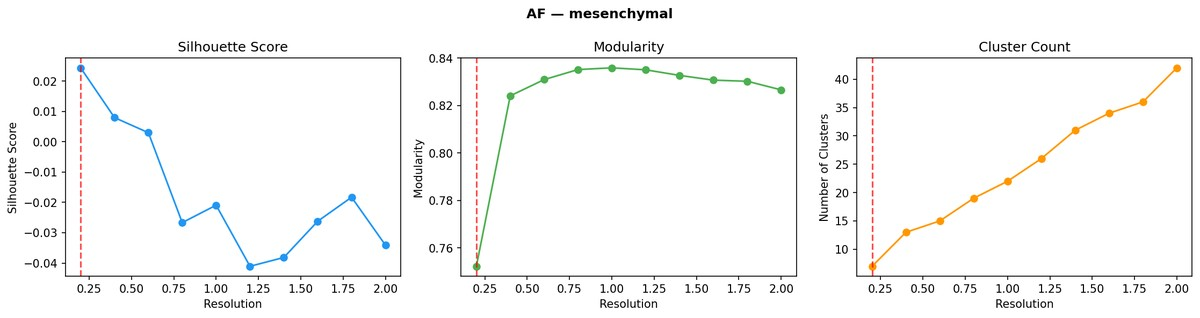

#### Af Non Mesenchymal

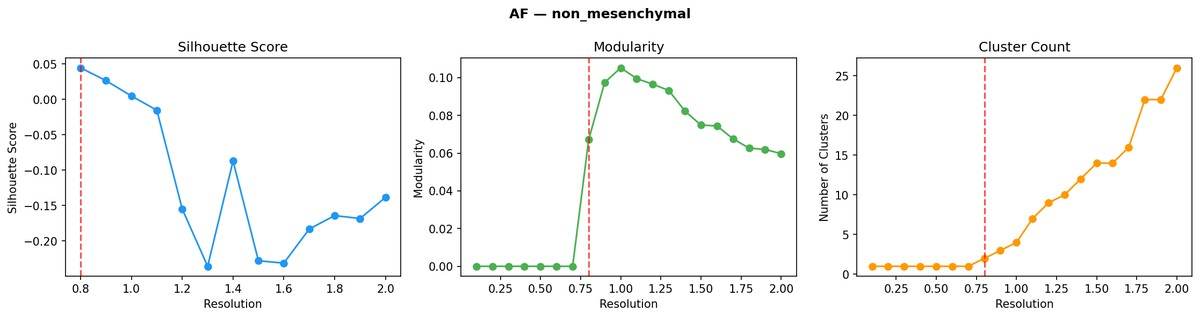

#### Cep Mesenchymal

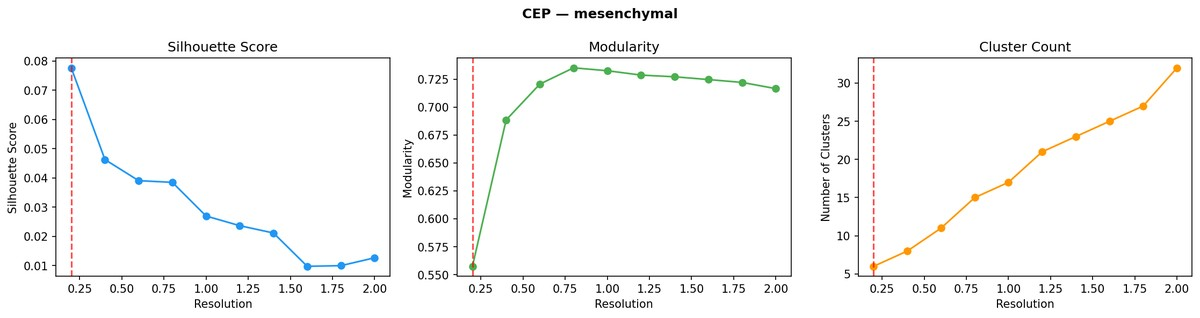

#### Cep Non Mesenchymal

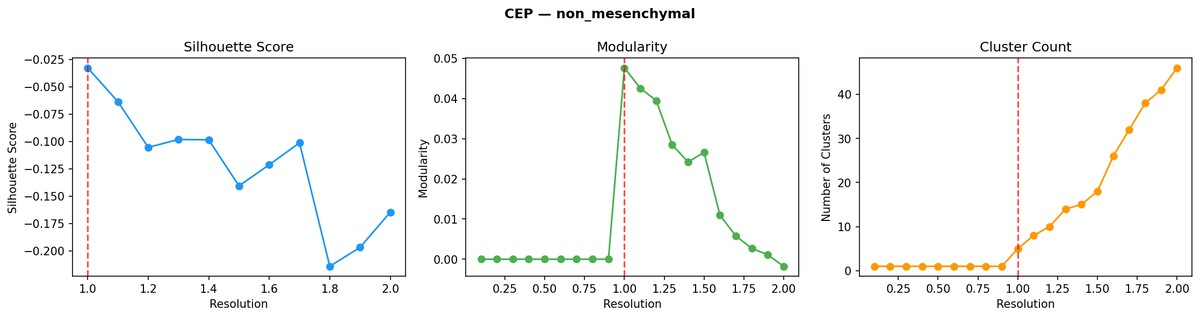

#### Np Mesenchymal

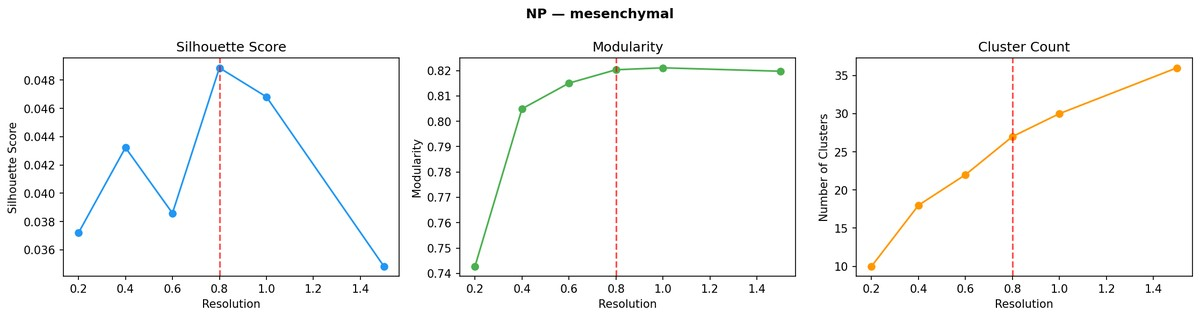

#### Np Non Mesenchymal

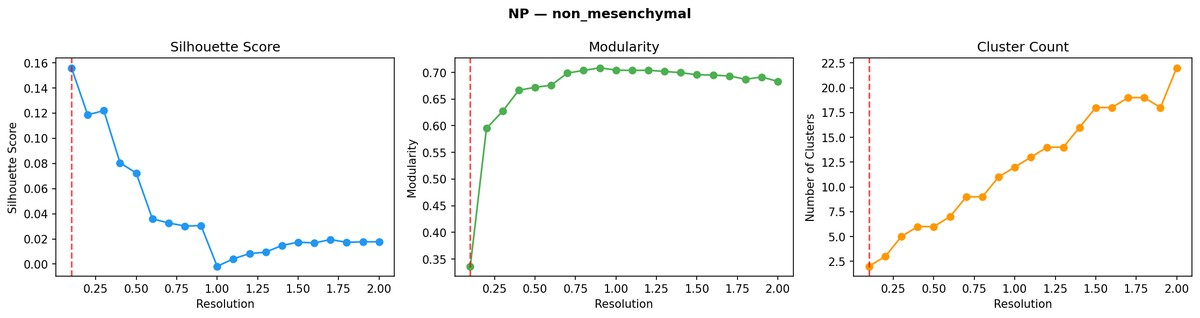

#### All Cells Mesenchymal

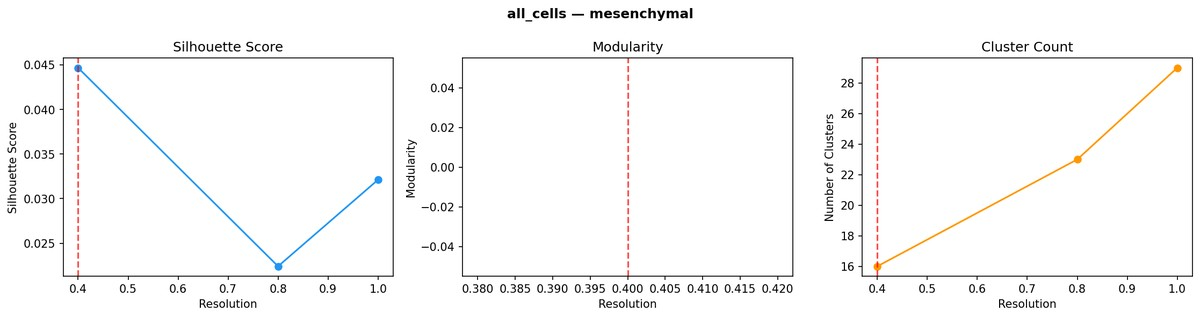

#### All Cells Non Mesenchymal

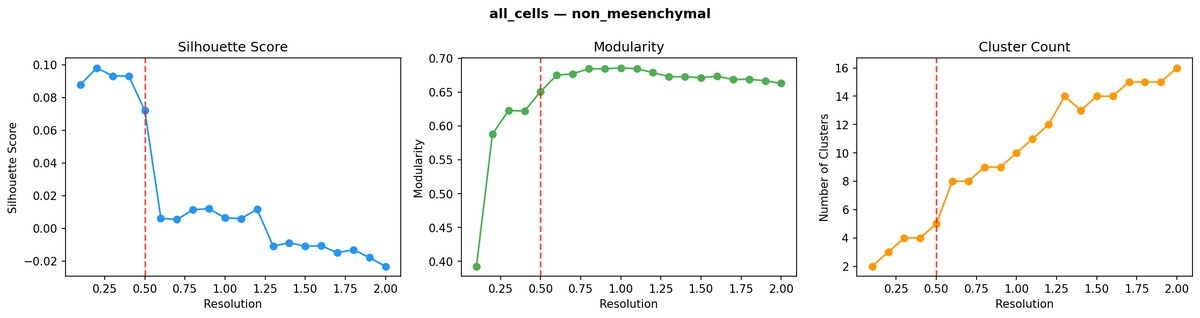

In [8]:
tv4_opt_plots = sorted(TV4_OPT_DIR.glob('*_optimization.png'))
print(f'Tiered v4 resolution optimization plots: {len(tv4_opt_plots)}')

for fpath in tv4_opt_plots:
    label = fpath.stem.replace('_optimization', '').replace('_', ' ').title()
    display(Markdown(f'#### {label}'))
    jpeg_bytes = _encode_jpeg(PILImage.open(fpath))
    display(Image(data=jpeg_bytes, format='jpeg'))


### 5c. Resolution scan tables — tiered v4

Full per-resolution silhouette and modularity values.


In [9]:
tv4_res_tables = sorted(TV4_OPT_DIR.glob('*_resolutions.tsv'))
print(f'Tiered v4 resolution scan tables: {len(tv4_res_tables)}')

for fpath in tv4_res_tables:
    label = fpath.stem.replace('_resolutions', '').replace('_', ' ').title()
    df = pd.read_csv(fpath, sep='\t')
    display(Markdown(f'#### {label}'))
    display(df.style.set_caption(f'{label} — Resolution Scan Results').format(precision=4))


Tiered v4 resolution scan tables: 8


#### Af Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.2000,7,0.0243,0.7522
1,0.4000,13,0.0079,0.8241
2,0.6000,15,0.0030,0.8309
3,0.8000,19,-0.0267,0.8351
4,1.0000,22,-0.0209,0.8359
5,1.2000,26,-0.0411,0.8350
6,1.4000,31,-0.0382,0.8327
7,1.6000,34,-0.0262,0.8307
8,1.8000,36,-0.0183,0.8302
9,2.0000,42,-0.0341,0.8266


#### Af Non Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.1000,1,nan,0.0000
1,0.2000,1,nan,0.0000
2,0.3000,1,nan,0.0000
3,0.4000,1,nan,0.0000
4,0.5000,1,nan,0.0000
5,0.6000,1,nan,0.0000
6,0.7000,1,nan,0.0000
7,0.8000,2,0.0444,0.0672
8,0.9000,3,0.0263,0.0975
9,1.0000,4,0.0046,0.1053


...

,resolution,n_clusters,silhouette,modularity
0,0.1000,2,0.1560,0.3365
1,0.2000,3,0.1187,0.5950
2,0.3000,5,0.1219,0.6273
3,0.4000,6,0.0805,0.6667
4,0.5000,6,0.0724,0.6720
5,0.6000,7,0.0360,0.6759
6,0.7000,9,0.0327,0.6988
7,0.8000,9,0.0302,0.7037
8,0.9000,11,0.0306,0.7085
9,1.0000,12,-0.0017,0.7043


#### All Cells Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.4000,16,0.0447,nan
1,0.8000,23,0.0224,nan
2,1.0000,29,0.0321,nan


#### All Cells Non Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.1000,2,0.0879,0.3925
1,0.2000,3,0.0982,0.5879
2,0.3000,4,0.0932,0.6227
3,0.4000,4,0.0932,0.6221
4,0.5000,5,0.0720,0.6508
5,0.6000,8,0.0062,0.6749
6,0.7000,8,0.0053,0.6771
7,0.8000,9,0.0114,0.6845
8,0.9000,9,0.0119,0.6845
9,1.0000,10,0.0063,0.6859


### 5d. Cluster UMAPs per compartment-tier — tiered v4

UMAPs are stored per tier in `obsm['X_umap']`. Each tier is plotted
separately and colored by its tier-specific Leiden labels
(`leiden_mesenchymal`, `leiden_non_mesenchymal`).


#### NP

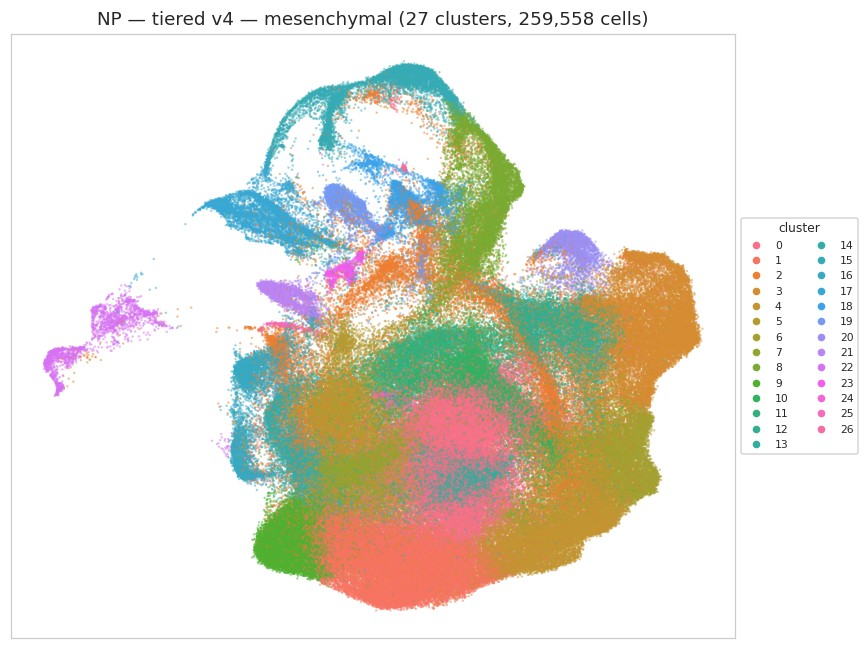

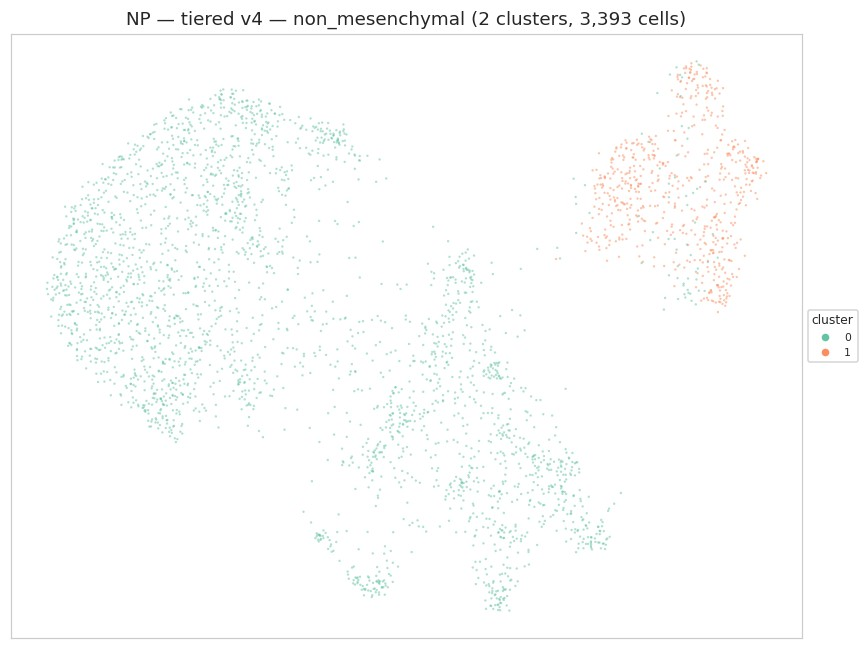

#### AF

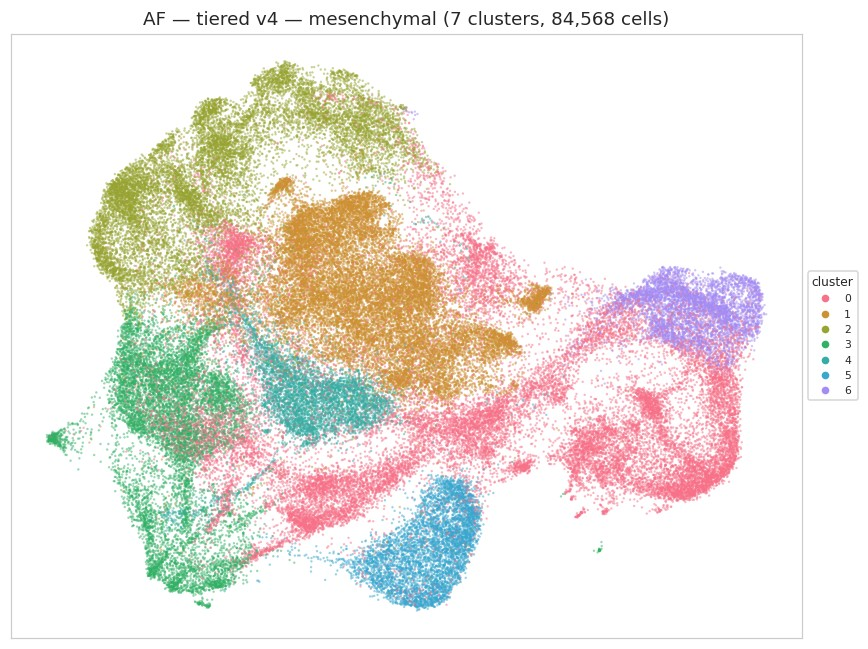

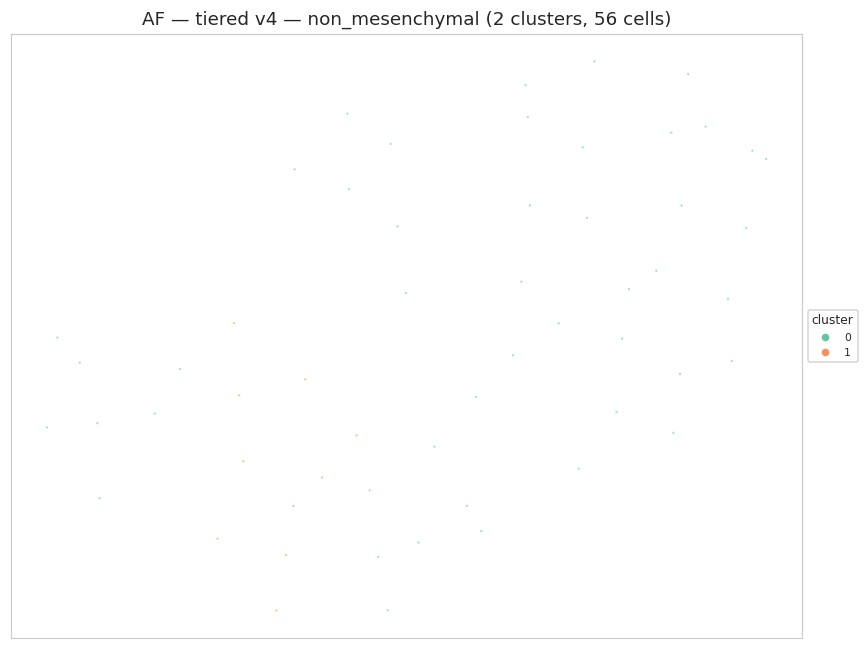

#### CEP

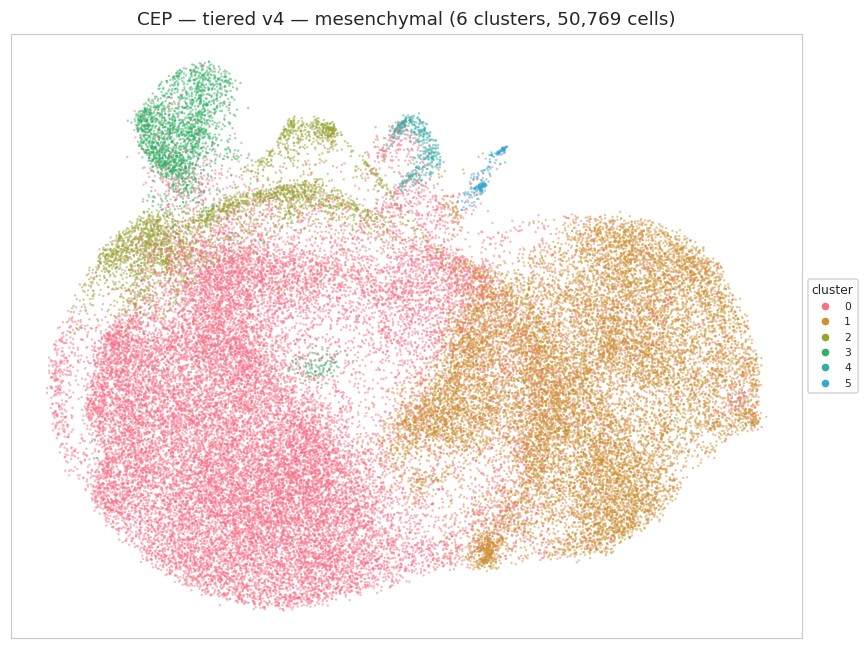

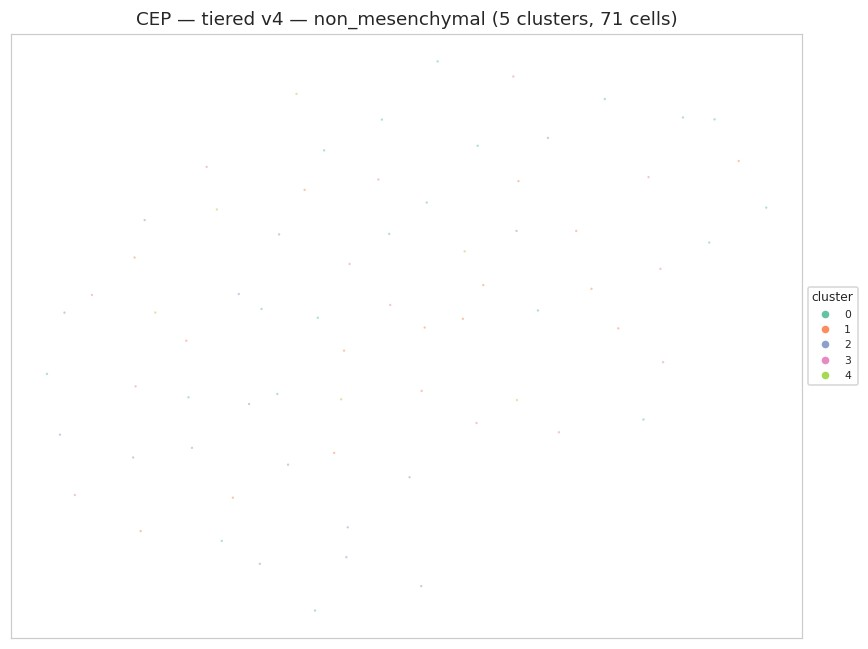

#### all_cells

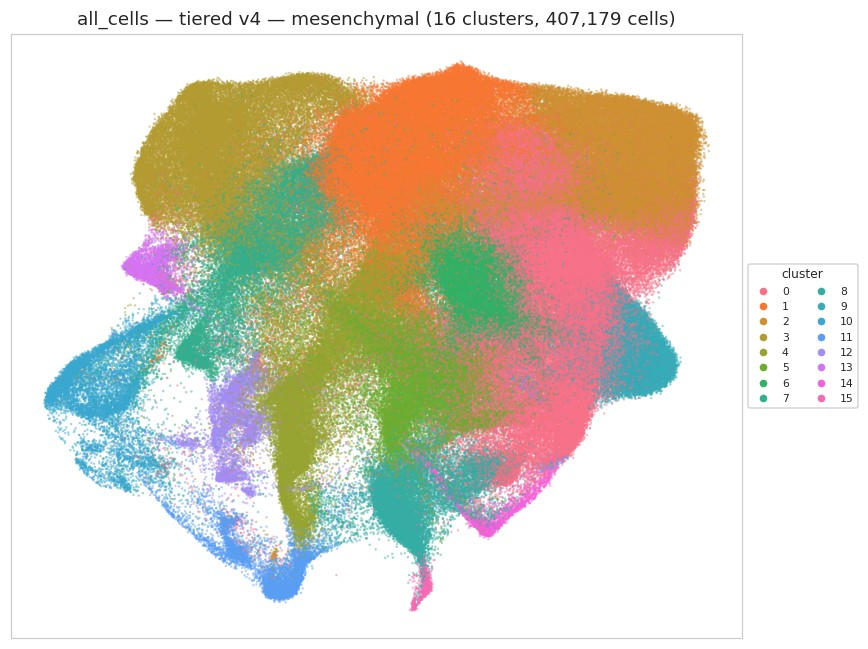

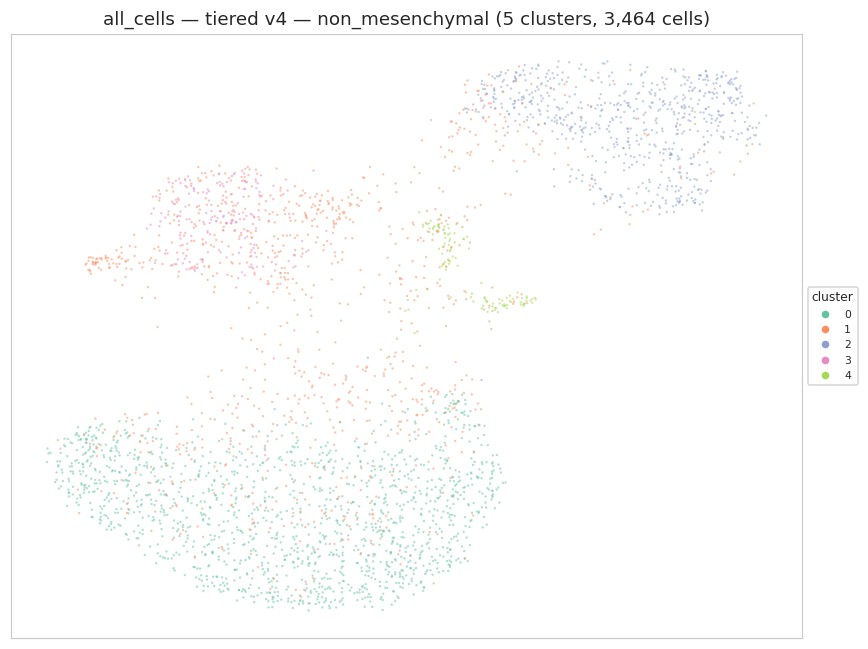

In [10]:
def _plot_tier_umap(comp_name, comp_path, tier, leiden_col, palette_name='husl'):
    adata = sc.read_h5ad(comp_path, backed='r')
    obs = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    if leiden_col not in obs.columns or 'tier' not in obs.columns:
        adata.file.close()
        return False
    mask = (obs['tier'].astype(str) == tier) & (obs[leiden_col].astype(str) != 'NA')
    if mask.sum() < 5:
        adata.file.close()
        return False
    umap = adata.obsm['X_umap'][:][mask.values]
    labels = obs.loc[mask, leiden_col].astype(str).values
    adata.file.close()

    finite = np.isfinite(umap).all(axis=1)
    umap = umap[finite]; labels = labels[finite]
    if len(umap) < 5:
        return False

    uniq = sorted(set(labels), key=lambda x: int(x) if x.isdigit() else x)
    palette = dict(zip(uniq, sns.color_palette(palette_name, max(len(uniq), 8))))
    idx = np.random.RandomState(42).permutation(len(umap))
    colors = [palette[labels[i]] for i in idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=0.3, alpha=0.5, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{comp_name} — tiered v4 — {tier} '
                 f'({len(uniq)} clusters, {len(umap):,} cells)', fontsize=12)
    handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[c],
                       markersize=6, label=c) for c in uniq]
    ax.legend(handles=handles, title='cluster', fontsize=7, title_fontsize=8,
              loc='center left', bbox_to_anchor=(1.0, 0.5),
              ncol=2 if len(uniq) > 12 else 1)
    fig.tight_layout()
    render_fig(fig)
    return True

for comp_name, comp_path in TV4_COMPARTMENTS.items():
    display(Markdown(f'#### {comp_name}'))
    _plot_tier_umap(comp_name, comp_path, 'mesenchymal', 'leiden_mesenchymal')
    plotted_nm = _plot_tier_umap(comp_name, comp_path, 'non_mesenchymal',
                                  'leiden_non_mesenchymal', palette_name='Set2')
    if not plotted_nm:
        print(f'  {comp_name}: no non_mesenchymal tier (or too few cells)')


### 5e. Cluster size distributions — tiered v4

Per-tier cluster sizes for each compartment.


#### NP

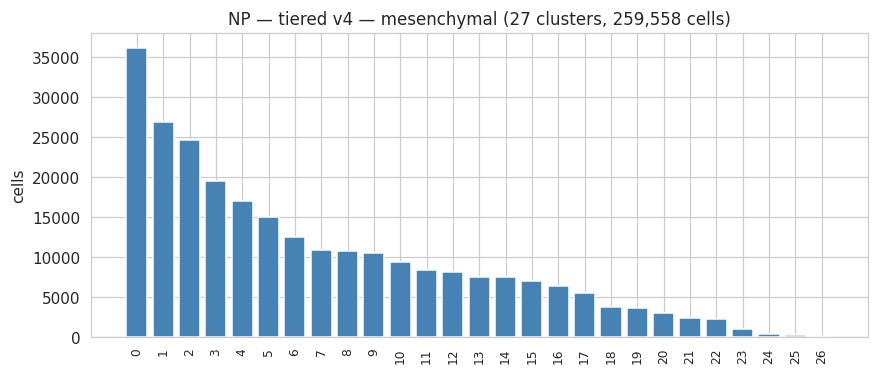

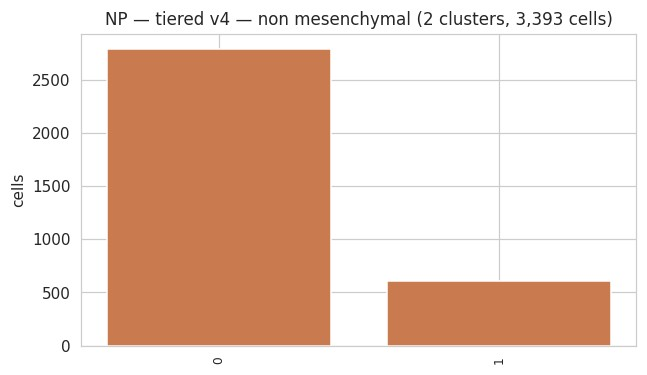

#### AF

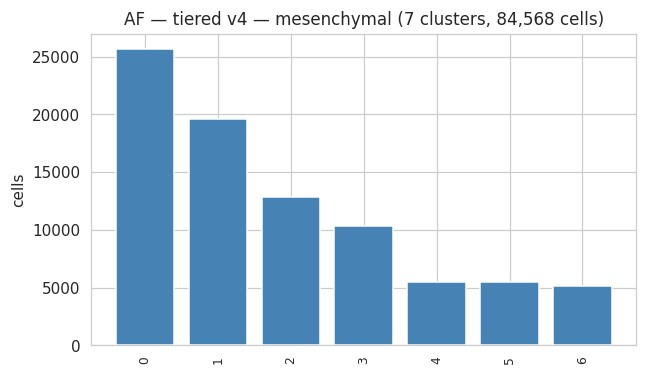

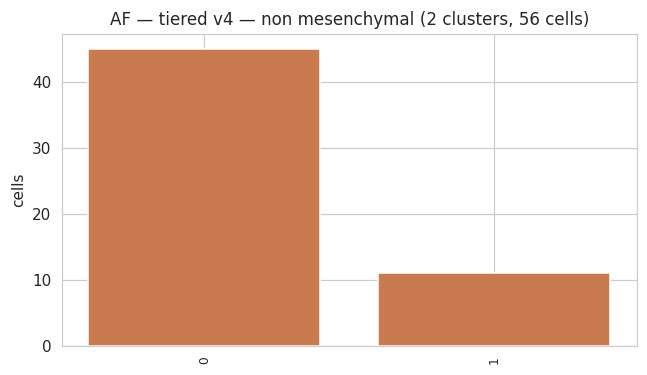

#### CEP

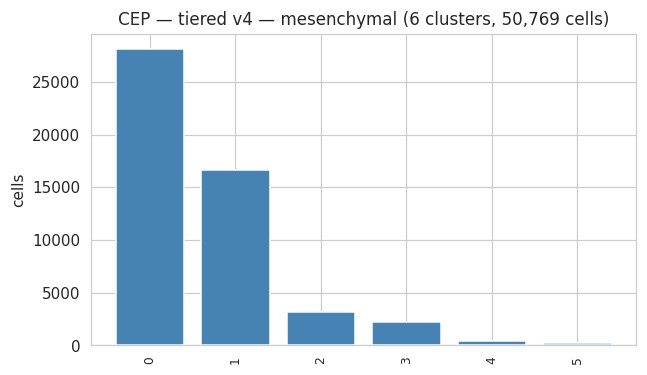

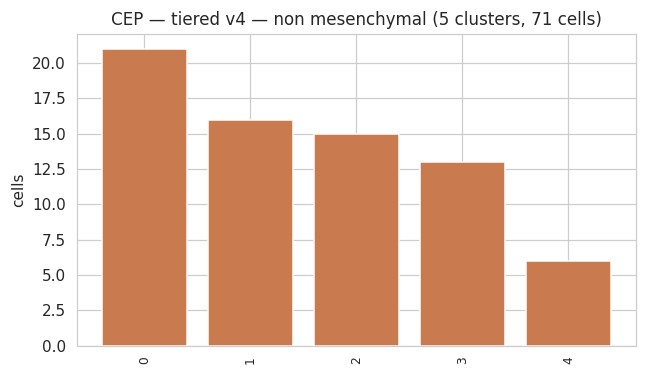

#### all_cells

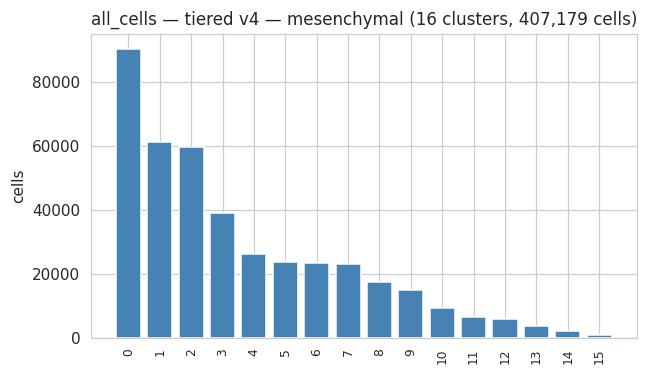

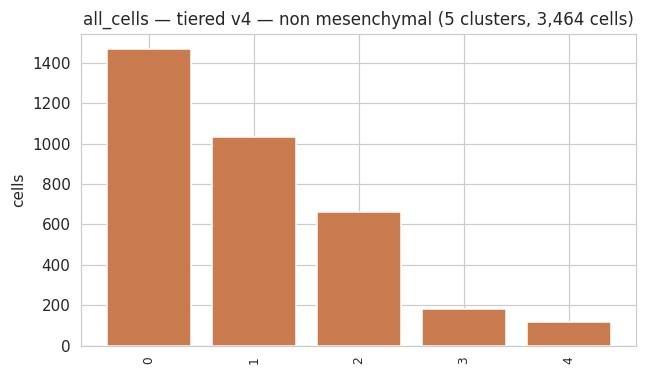

In [11]:
def _bar_tier_clusters(comp_name, comp_path, leiden_col, color):
    adata = sc.read_h5ad(comp_path, backed='r')
    obs = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()
    if leiden_col not in obs.columns:
        return False
    s = obs[leiden_col].astype(str)
    s = s[s != 'NA']
    if len(s) == 0:
        return False
    counts = s.value_counts().sort_index(
        key=lambda x: x.astype(int) if x.str.isdigit().all() else x)
    fig, ax = plt.subplots(figsize=(max(6, len(counts) * 0.3), 3.5))
    ax.bar(range(len(counts)), counts.values, color=color, edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=90, fontsize=8)
    ax.set_ylabel('cells')
    tier_label = leiden_col.replace('leiden_', '').replace('_', ' ')
    ax.set_title(f'{comp_name} — tiered v4 — {tier_label} '
                 f'({len(counts)} clusters, {len(s):,} cells)', fontsize=11)
    fig.tight_layout()
    render_fig(fig)
    return True

for comp_name, comp_path in TV4_COMPARTMENTS.items():
    display(Markdown(f'#### {comp_name}'))
    _bar_tier_clusters(comp_name, comp_path, 'leiden_mesenchymal', 'steelblue')
    plotted_nm = _bar_tier_clusters(comp_name, comp_path, 'leiden_non_mesenchymal', '#c97a4f')
    if not plotted_nm:
        print(f'  {comp_name}: no non_mesenchymal tier')


### 5f. Open questions for the human reviewer

Pipeline is stopped here pending human approval before Module 07.

1. **NP mes resolution choice (27 clusters at res = 0.8).** The silhouette curve
   is nearly flat across res = 0.4–1.0 (see §5b/5c); the same data clusters into
   ~18–30 clusters within ~10 % silhouette noise. Is 27 too fine for ~5 broad
   NP cell types, or appropriate for resolving the mature_chondrocyte ↔
   fibrocartilaginous gradient states?
2. **AF mes coarseness (7 clusters at res = 0.2).** Silhouette is barely above
   zero across all resolutions. Picking the silhouette peak gave coarser
   clusters than v5 (12). Is 7 enough for AF biology, or should we override to
   a higher resolution?
3. **NP non-mes (3,393 cells, 2 clusters at res = 0.1).** With the
   `min_resolution = 0.5` floor dropped, the silhouette peak now lands at
   res = 0.1, collapsing the previous 6 non-mes clusters down to 2. Is this the
   right choice biologically — i.e. are NP non-mesenchymal cells genuinely just
   a couple of broad states, or should we override the silhouette pick and
   keep the finer 6-cluster solution from the prior run?
4. **CEP non-mes (71 cells, 5 clusters at res = 1.0).** Selected on its own
   without the resolution floor. Is this tier worth carrying through Module 07+
   at all, or should it be dropped and the cells reassigned to all_cells non-mes?
5. **AF non-mes (56 cells, 2 clusters at res = 0.8).** Newly created on
   2026-05-06 after the 05k threshold was relaxed to ≥ 5 cells per study. With
   only 56 cells, is this tier worth carrying through, or should AF non-mes
   cells continue to be analysed only via `all_cells.h5ad`?

**Phase-5 gates (per `docs/np_switch_to_tiered_v4_plan.md`)** still need to be
evaluated for all four compartments before declaring tiered v4 the primary
atlas: ≥ 80 % top-100 DE concordance with v5, ≥ 5 of 10 v5 significant pain
genes recovered, max_study_pct < 85 % per cluster, pseudobulk power ≥ v5's 17
powered comparisons. These cannot be evaluated until Modules 07–08 run.


## 6. Status

### v5 atlas (CCA-flat) — Module 06 complete (2026-03-25)
- Leiden clustering on CCA latent space with automated resolution optimization
- Separate clustering for mesenchymal and non-mesenchymal tiers
- NP: 12 · AF: 12 · CEP: 9 · all_cells: 15 clusters
- Cluster labels stored in `leiden`; tier-specific in `leiden_mesenchymal`,
  `leiden_non_mesenchymal`

### Tiered v4 atlas — Module 06 complete, awaiting human checkpoint (2026-05-06)
- Leiden clustering on per-tier Seurat v4 SCT + CCA embeddings
- NP: 29 (27 mes @ res 0.8 + 2 non-mes @ res 0.1)
- AF: 9 (7 mes @ res 0.2 + 2 non-mes @ res 0.8)
- CEP: 11 (6 mes @ res 0.2 + 5 non-mes @ res 1.0)
- all_cells: 21 (16 mes @ res 0.4 + 5 non-mes @ res 0.5)
- All blob and study-cluster ARI checks pass (max ARI 0.066, NP)
- Cluster labels stored in `leiden` (with `M`/`NM` prefix), `leiden_mesenchymal`,
  `leiden_non_mesenchymal`
- **Pipeline stopped at the human checkpoint before Module 07.**
  See §5f for review questions.
